# Päivystyksen hoitoajan visualisointi PROC BOX -proseduurilla

## Tiivistelmä

Sairaalan toiminta-analyysi, joka käyttää PROC BOXPLOT -proseduuria (aliaksena PROC BOX) vertailemaan päivystyksen hoitoaikaa kolmen kliinisen palvelun välillä. Vierekkäiset skemaattiset laatikko-jana-kuviot näyttävät kunkin palvelun mediaanin, kvartiilit, keskiarvon ja pitkien hoitoaikojen poikkeavat havainnot yhdellä silmäyksellä.

100 simuloidun käynnin joukossa hoitoajan mediaani nousee tasaisesti **40,0 tunnista sisätaudeilla (Sisätaudit)** **50,4 tuntiin kirurgiassa (Kirurgia)** ja **60,5 tuntiin traumapuolella (Trauma)**, ja keskiarvot noudattavat samaa järjestystä (41,6, 54,6, 62,8 tuntia). Kirurgiassa on kolme korkeaa poikkeavaa havaintoa ylimmän viiksen yläpuolella (jopa 84,3 tuntia) — nämä ovat odotustapaukset, jotka kuluttavat eniten vuodepaikkatunteja. Notebook piirtää vertailun kolmella tavalla: skemaattinen kuvio, keskiarvotrendin päällekkäisasettelu ja vaakasuora asettelu.

## Tietolähteet

Kaikki data luodaan sisäisesti ensimmäisessä DATA step -vaiheessa (`call streaminit(20260531)`); ulkoista tai verkkosyötettä ei käytetä.

**`ed_los`** — yksi rivi jokaista päivystyskäyntiä kohti (100 riviä)

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------------|
| `PatientID` | Num | Juokseva käynnin tunniste (1-100) |
| `Department` | Char(16) | Hoitava palvelu: Sisätaudit, Kirurgia, Trauma |
| `Severity` | Char(16) | Triage-kiireellisyys: Rutiini (~55 %), Kiireellinen (~30 %), Kriittinen (~15 %) |
| `LOS_Hours` | Num | Hoitoaika tunteina; palvelun ja vaikeusasteen mukaan määräytyvä keskiarvo sekä normaalijakautunut kohina, ajoittaisella pitkän hoitoajan sokilla (nimike "Hoitoaika (tuntia)") |

Toteutunut jakauma on Sisätaudit 34 / Kirurgia 36 / Trauma 30 käyntiä, ja triage-kiireellisyyden mukaan Rutiini 51 / Kiireellinen 35 / Kriittinen 14.

# Päivystyksen hoitoajan visualisointi PROC BOX -proseduurilla

Hoitoaika (LOS, length of stay) on yksi tarkimmin seuratuista toiminnallisista mittareista sairaalan päivystyksessä: se vaikuttaa vuodepaikkojen saatavuuteen, henkilöstömitoitukseen, potilasvirtaan ja laatupisteisiin. Pelkät keskiarvot kätkevät tarinan — toimintatiimille merkitystä on hoitoaikojen *hajonnalla*, resursseja sitovilla *poikkeavilla havainnoilla* ja sillä, miten jakaumat eroavat kliinisten palvelujen välillä.

PROC BOX (PROC BOXPLOT -proseduurin alias) on rakennettu juuri tähän vertailuun. Se piirtää vierekkäisiä laatikko-jana-kuvioita, jotka merkitsevät kunkin ryhmän mediaanin, kvartiilit, keskiarvon ja ääriarvot, joten analyytikko voi lukea jokaisen palvelun hoitoaikajakauman muodon yhdellä silmäyksellä.

Tässä notebookissa me:

1. Luomme synteettisen päivystyskäyntien tietoaineiston, joka sopii 100 havainnon ympäristöön.
2. Tuotamme skemaattisen laatikkokuvion hoitoajasta osastoittain sekä siihen liittyvän tilastotaulukon.
3. Asetamme päälle keskiarvotrendiviivan `BOXCONNECT=MEAN`-asetuksella tehdäksemme palvelujen välisen gradientin näkyväksi.
4. Piirrämme saman vertailun uudelleen vaakasuorana `HORIZONTAL`-asetuksella.

## Vaihe 1 — Luo synteettinen päivystyskäyntien data

Simuloimme 100 päivystyskäyntiä. Jokaiselle potilaalle määritetään yksi kolmesta kliinisestä palvelusta (Sisätaudit, Kirurgia, Trauma) ja triage-vaikeusaste (Rutiini, Kiireellinen, Kriittinen). Hoitoaika rakennetaan palvelukohtaisesta perustasosta, jota siirretään ylöspäin kiireellisemmillä potilailla, normaalijakautuneen kohinan kera. Pieni osa käynneistä saa ylimääräisen pitkän hoitoajan sokin jäljittelemään sitä raskasta oikeaa häntää, jonka todellinen päivystysdata aina näyttää (odotustapaukset, vuodeosastopaikkaa odottavat sisäänotot). Kiinteä siemenluku `call streaminit` -kutsussa tekee aineistosta täysin toistettavan.

In [1]:
ASETUKSET linesize=96;

TIEDOT ed_los;
   CALL streaminit(20260531);
   PITUUS Department $ 16 Severity $ 16;
   TEE PatientID = 1 ASTI 100;
      d = rand('integer', 1, 3);
      /* palvelun nimi ilman _temporary_ -taulukkoa (monitavuiset arvot) */
      JOS d = 1 NIIN Department = 'Sisätaudit';
      MUUTEN JOS d = 2 NIIN Department = 'Kirurgia';
      MUUTEN Department = 'Trauma';
      dept_order = d;

      u = rand('uniform');
      JOS u < 0.55 NIIN s = 1;
      MUUTEN JOS u < 0.85 NIIN s = 2;
      MUUTEN s = 3;
      JOS s = 1 NIIN Severity = 'Rutiini';
      MUUTEN JOS s = 2 NIIN Severity = 'Kiireellinen';
      MUUTEN Severity = 'Kriittinen';

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      JOS rand('uniform') < 0.06 NIIN
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      JOS LOS_Hours < 2 NIIN LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      TULOSTE;
   LOPPU;
   POISTA d u s BASE;
   NIMIKE LOS_Hours = 'Hoitoaika (tuntia)' Department = 'Palvelu' Severity = 'Vaikeusaste';
SUORITA;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Vaihe 2 — Lajittele ryhmämuuttujan mukaan

PROC BOX olettaa, että ryhmämuuttuja (vaaka-akseli) on lajiteltu niin, että kunkin ryhmän havainnot ovat peräkkäisiä. Lajittelemme muuttujan `Department` mukaan ennen kuvion piirtämistä.

In [2]:
PROSEDUURI LAJITTELE TIEDOT=ed_los;
   MUKAAN dept_order Department;
SUORITA;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 5 columns).
NOTE: PROC SORT statement used.


## Vaihe 3 — Skemaattinen laatikkokuvio

Ydinanalyysi. Syntaksi `PLOT analysis-var * group-var` pyytää yhden laatikon osastoa kohti. `BOXSTYLE=SCHEMATIC` tuottaa klassisen Tukeyn skemaattisen kuvion: viikset ulottuvat äärimmäisimpiin havaintoihin 1,5-kertaisen kvartiilivälin sisällä, ja kaikki sen ulkopuoliset pisteet piirretään yksittäin poikkeavina havaintoina — ihanteellinen kapasiteettia kuormittavien pitkien hoitoaikojen havaitsemiseen.

`NOHLABEL` estää tarpeettoman vaaka-akselin nimikkeen, koska osastojen nimet ovat itsestäänselviä. Kuvion ohella PROC BOXPLOT tulostaa tilastotaulukon, joka antaa kunkin osaston N:n, minimin, kvartiilit, mediaanin, maksimin, keskiarvon ja keskihajonnan.

                              Päivystyksen hoitoaika palveluittain                              

                             Päivystyksen hoitoaika palveluittain

                                     The BOXPLOT Procedure

Schematic Plots for Hoitoaika (tuntia)

Palvelu               N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Sisätaudit           34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Kirurgia             36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Päivystyksen hoitoaika palveluittain.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


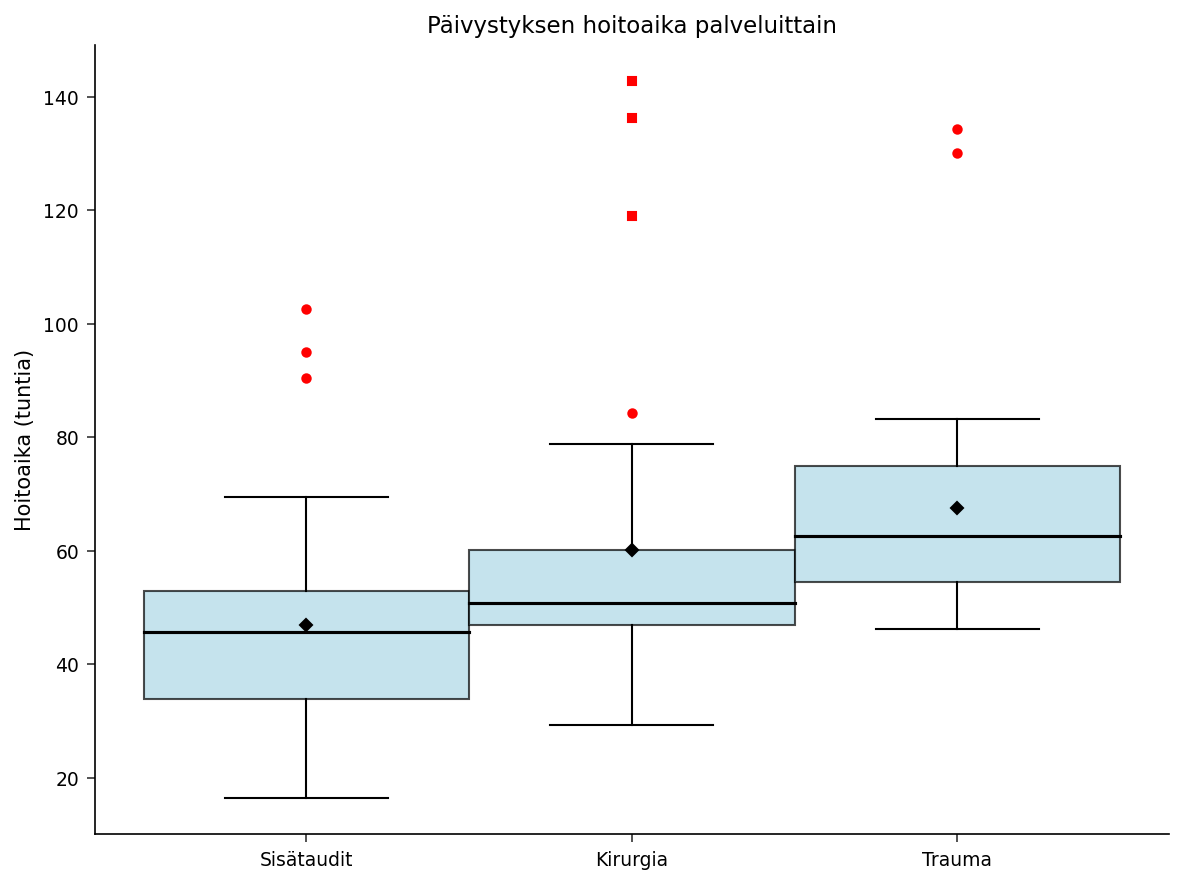

In [3]:
OTSIKKO 'Päivystyksen hoitoaika palveluittain';
PROSEDUURI boxplot TIEDOT=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
   NIMIKE LOS_Hours = 'Hoitoaika (tuntia)' Department = 'Palvelu';
SUORITA;

## Vaihe 4 — Aseta päälle keskiarvotrendiviiva

Tehdäksemme palvelusta palveluun etenevän gradientin näkyväksi lisäämme `BOXCONNECT=MEAN`. PROC BOXPLOT piirtää tällöin yhdistävän viivan kunkin laatikon keskiarvon (vinoneliömerkit) läpi, muuttaen kolme erillistä jakaumaa yhdeksi luettavaksi trendiksi. Koska osastot ovat järjestyksessä Sisätaudit → Kirurgia → Trauma, nouseva yhdysviiva tiivistää keskimääräisen hoitoajan kasvun yhdellä vedolla — hyödyllinen vihje toimintakojelaudalle.

                     Päivystyksen hoitoaika palveluittain - keskiarvotrendi                     

                    Päivystyksen hoitoaika palveluittain - keskiarvotrendi

                                     The BOXPLOT Procedure

Schematic Plots for Hoitoaika (tuntia)

Palvelu               N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Sisätaudit           34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Kirurgia             36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Päivystyksen hoitoaika palveluittain - keskiarvotrendi.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


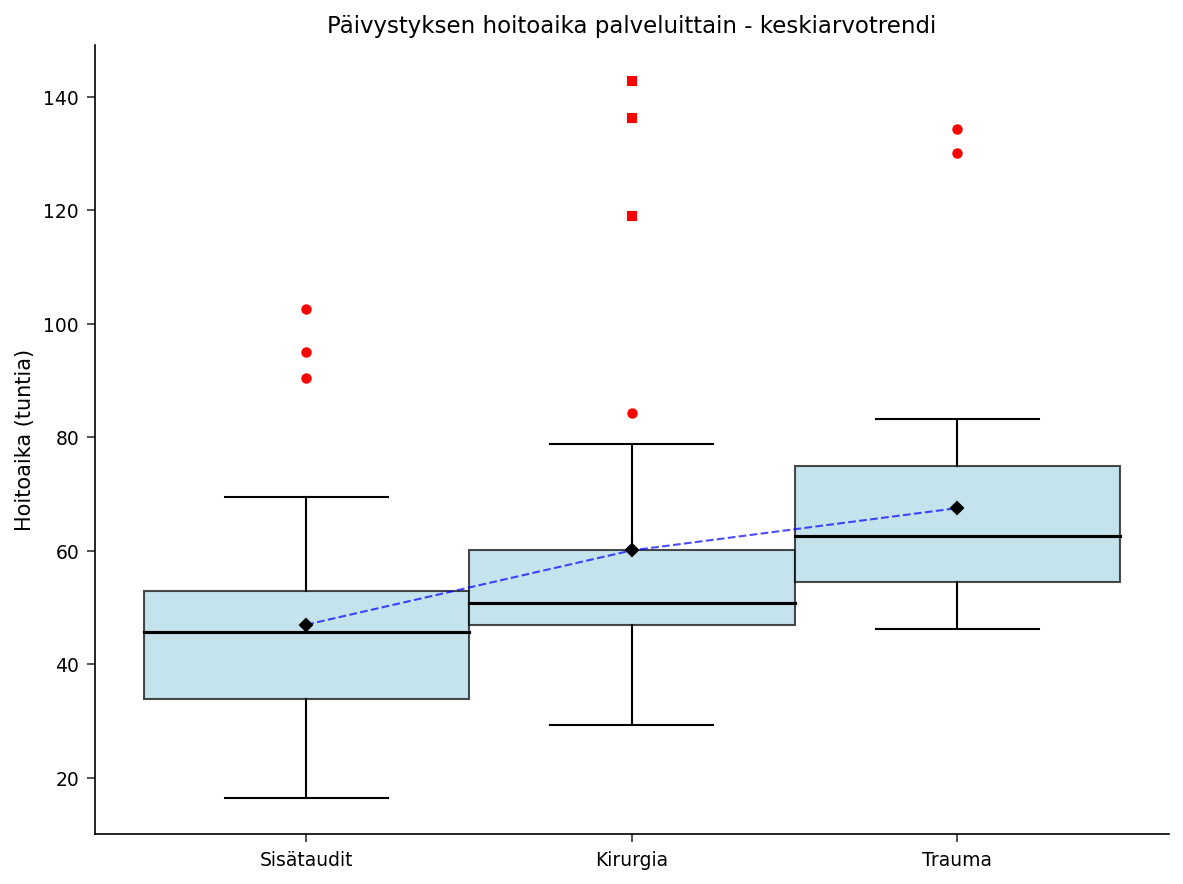

In [4]:
OTSIKKO 'Päivystyksen hoitoaika palveluittain - keskiarvotrendi';
PROSEDUURI boxplot TIEDOT=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
   NIMIKE LOS_Hours = 'Hoitoaika (tuntia)' Department = 'Palvelu';
SUORITA;

## Vaihe 5 — Vaakasuora asettelu

Sama vertailu näyttää luontevalta kyljelleen käännettynä. `HORIZONTAL`-asetuksen lisääminen vaihtaa akselit niin, että laatikot kulkevat vasemmalta oikealle vasteen ollessa x-akselilla — asettelu, joka skaalautuu paremmin, kun palvelujen nimet ovat pitkiä tai lukuisia, ja jota monet toimintakojelaudat suosivat. Tilastot ovat identtiset pystysuoran näkymän kanssa; vain suunta muuttuu.

                       Päivystyksen hoitoaika palveluittain - vaakasuora                        

                       Päivystyksen hoitoaika palveluittain - vaakasuora

                                     The BOXPLOT Procedure

Schematic Plots for Hoitoaika (tuntia)

Palvelu               N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Sisätaudit           34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Kirurgia             36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Päivystyksen hoitoaika palveluittain - vaakasuora.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


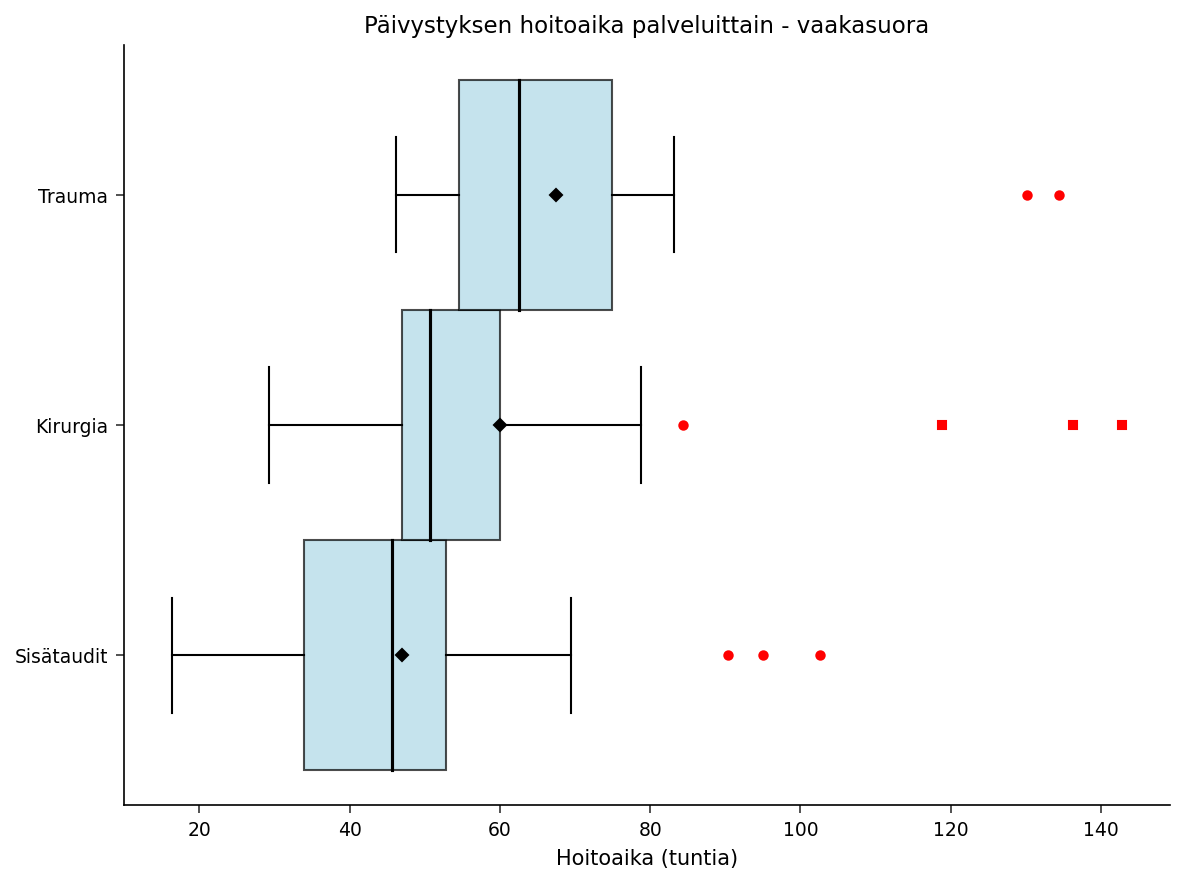

In [5]:
OTSIKKO 'Päivystyksen hoitoaika palveluittain - vaakasuora';
PROSEDUURI boxplot TIEDOT=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
   NIMIKE LOS_Hours = 'Hoitoaika (tuntia)' Department = 'Palvelu';
SUORITA;

## Tulosten tulkinta

Laatikkokuviot ja niihin liittyvä tilastotaulukko muuntavat raa'an hoitoaikadatan toiminnallisesti hyödynnettäväksi kuvaksi:

- **Selkeä palvelugradientti.** Hoitoajan mediaani nousee monotonisesti kolmen palvelun välillä: **Sisätaudit 40,0 h → Kirurgia 50,4 h → Trauma 60,5 h**. Keskiarvot kertovat saman tarinan (41,6, 54,6, 62,8 h), ja vaiheen 4 `BOXCONNECT=MEAN`-viiva piirtää kasvun yhtenä nousevana trendinä. Traumapotilaat viipyvät keskimäärin noin 50 % pidempään kuin sisätautipotilaat.

- **Vaihtelu on yhtä tärkeää kuin mediaani.** Kvartiiliväli (laatikon korkeus) on leveimmillään sisätaudeilla (Sisätaudit, Q1 32,8 h – Q3 51,2 h, 18,3 tunnin hajonta) ja kapeimmillaan traumapuolella (Trauma, Q1 54,5 h – Q3 68,5 h, 14,0 tunnin hajonta). Sisätaudit eivät siis ole vain lyhyin palvelu vaan myös vähiten ennustettava — ominaisuus, joka vaikeuttaa vuodepaikkojen hallinnan ennustamista.

- **Poikkeavat havainnot merkitsevät odotustapaukset.** Skemaattiset viikset pysähtyvät kohtaan 1,5 × kvartiiliväli, joten kolme punaista pistettä kirurgian ylimmän viiksen yläpuolella (huippuna 84,3 h) erottuvat aitoina pitkinä hoitoaikoina — juuri niinä odotustapauksina, jotka kuluttavat suhteettoman paljon vuodepaikkatunteja. Sisätaudit ja trauma eivät näytä tässä otoksessa yhtään pistettä viiksiensä ulkopuolella.

- **Vaihteluväli kertoo kapasiteettisuunnittelun tarinan.** Havaitut hoitoajat vaihtelevat välillä 16,3–69,5 h sisätaudeilla, 29,3–84,3 h kirurgiassa ja 46,1–83,2 h traumapuolella. Trauma ei koskaan tuota lyhyttä hoitoaikaa (sen minimi, 46,1 h, ylittää sisätautien mediaanin), mikä on juuri sitä, mitä toimintatiimi odottaisi resurssi-intensiivisimmältä palvelulta.

Yhdessä nämä näkymät antavat päivystyksen johtoryhmälle perustellun, jakaumatietoisen pohjan henkilöstö- ja kapasiteettisuunnitteluun — huomattavasti informatiivisemman kuin osastojen keskimääräisten hoitoaikojen vertailu yksinään.